# Brain MRI (magnetic resonance imaging) segmentation

## The task

This project addresses the segmentation of FLAIR abnormalities in brain MR images. Each image in the dataset is paired with a manually created FLAIR abnormality segmentation mask, so the goal is to segment the abnormal (tumor) region in lower-grade glioma cases.

Source kaggle challenge: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation/data

## Notebook structure

1. **The dataset:** source and download the content of dataset
2. **Exploration & Preparation:** structure of the segmentation dataset, pairing images with masks, visualization, train/val/test split and batch generators
3. **Metrics:** Dice coefficient, Dice loss and IoU coefficient
4. **Model:** the U-Net encoder–decoder architecture
5. **Training:** training loop, checkpointing and learning-curve monitoring
6. **Load model (optional):** reload the saved `unet.keras` weights
7. **Evaluation:** performance on the hold-out test set
8. **Prediction:** qualitative results on individual MRI slices
9. **Conclusions:** summary of results and possible extensions
10. **References:** dataset citations

Load every library used in the notebook

In [ ]:
import kagglehub
from glob import glob
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
import os, random
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from skimage.color import rgb2gray
from skimage.morphology import label
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from skimage.io import imread, imshow, concatenate_images

from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, Adamax

**Global settings:** 
- `TRAIN_SPLIT = 0.7` reserves 70% of the samples for training;
- `TEST_SPLIT = 0.5` later splits the remaining 30% into two equal halves (≈15% validation, ≈15% test).
- `RANDOM_STATE = 42` fixes the seed so the split is reproducible.

In [2]:
TRAIN_SPLIT = 0.7
TEST_SPLIT = 0.5
RANDOM_STATE = 42

os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## **1. The dataset**

The **LGG Segmentation Dataset** contains brain MR images together with manual FLAIR abnormality segmentation masks. The images were obtained from *The Cancer Imaging Archive* (TCIA) and correspond to **110 patients** included in *The Cancer Genome Atlas* (TCGA) lower-grade glioma collection, each having at least a fluid-attenuated inversion recovery (FLAIR) sequence and genomic cluster data available.

For more information on the genomic data, refer to the publication *"Comprehensive, Integrative Genomic Analysis of Diffuse Lower-Grade Gliomas"* and its supplementary material: https://www.nejm.org/doi/full/10.1056/NEJMoa1402121

**Download the dataset:** `kagglehub` pulls the LGG MRI segmentation dataset and returns the local path where it was extracted.

In [3]:
# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation


## **2. Exploration & Preparation**
Before training, the image/mask pairs must be collected in a DataFrame and prepared to be turned into batches the network can consume. This section builds that input pipeline.

### 2.1 Locate the masks 
Recursively collect the path of every file whose name contains `_mask`, print the total count, and show a few examples to verify the glob pattern matches. Every image where the name contains `_mask` is the mask of the associated mri.

The dataset is organized into 110 folders named after case ID that contains information about source institution.
Each folder contains MR images with the following naming convention:
- TCGA_\<institution-code\>\_\<patient-id\>\_\<slice-number\>.tif
- Corresponding masks have a `_mask` suffix.

In [4]:
masks_paths = glob("/kaggle/input/**/*mask*.*", recursive=True)

print("Number of masks:", len(masks_paths))

for i,path in enumerate(masks_paths[:3]):
    print(f"{i}) {path}")

Number of masks: 7858
0) /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif
1) /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_8_mask.tif
2) /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_34_mask.tif


### 2.2 Pair images with masks
Each MRI shares its mask's filename without the `_mask` suffix, so removing that suffix yields the image path. The two lists are combined into a `DataFrame` with `images_paths` and `masks_paths` columns.

In [5]:
images_paths = []

for i in masks_paths:
    images_paths.append(i.replace('_mask', ''))

df = pd.DataFrame(data= {'images_paths': images_paths, 'masks_paths': masks_paths})

### 2.3 Dataframe Exploration
**Preview:** show the first rows to confirm images and masks line up correctly.

In [6]:
df.head()

,images_paths,masks_paths
0,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
1,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
2,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
3,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
4,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...


**Descriptive stats:** as both columns are strings, this reports count, number of unique values and the most frequent entry rather than numeric statistics.

In [7]:
df.describe()

,images_paths,masks_paths
count,7858,7858
unique,7858,7858
top,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...,/kaggle/input/datasets/mateuszbuda/lgg-mri-seg...
freq,1,1


**Structure check:** report row count, column names, non-null counts and dtypes. It's a quick way to confirm no path is missing.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7858 entries, 0 to 7857
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   images_paths  7858 non-null   object
 1   masks_paths   7858 non-null   object
dtypes: object(2)
memory usage: 122.9+ KB


**Inspect one pair:** read the first image/mask from disk and print shape and dtype. The MRI is a 3-channel `(256, 256, 3)` RGB image while the mask is single-channel `(256, 256)`, both `uint8` in [0, 255].

In [ ]:
sample = 0

img = cv2.imread(df['images_paths'].iloc[sample])
msk = cv2.imread(df['masks_paths'].iloc[sample], cv2.IMREAD_GRAYSCALE)

print(f"Immagine: shape {img.shape}, dtype {img.dtype}")
print(f"Maschera: shape {msk.shape}, dtype {msk.dtype}")

Immagine: shape (256, 256, 3), dtype uint8
Maschera: shape (256, 256), dtype uint8


### 2.4 Visualization MRI images + Mask
**Visualization helper:** `plot_data` draws each pair on three panels:
- the MRI
- the binary mask
- an overlay with the tumor region blended in semi-transparent red

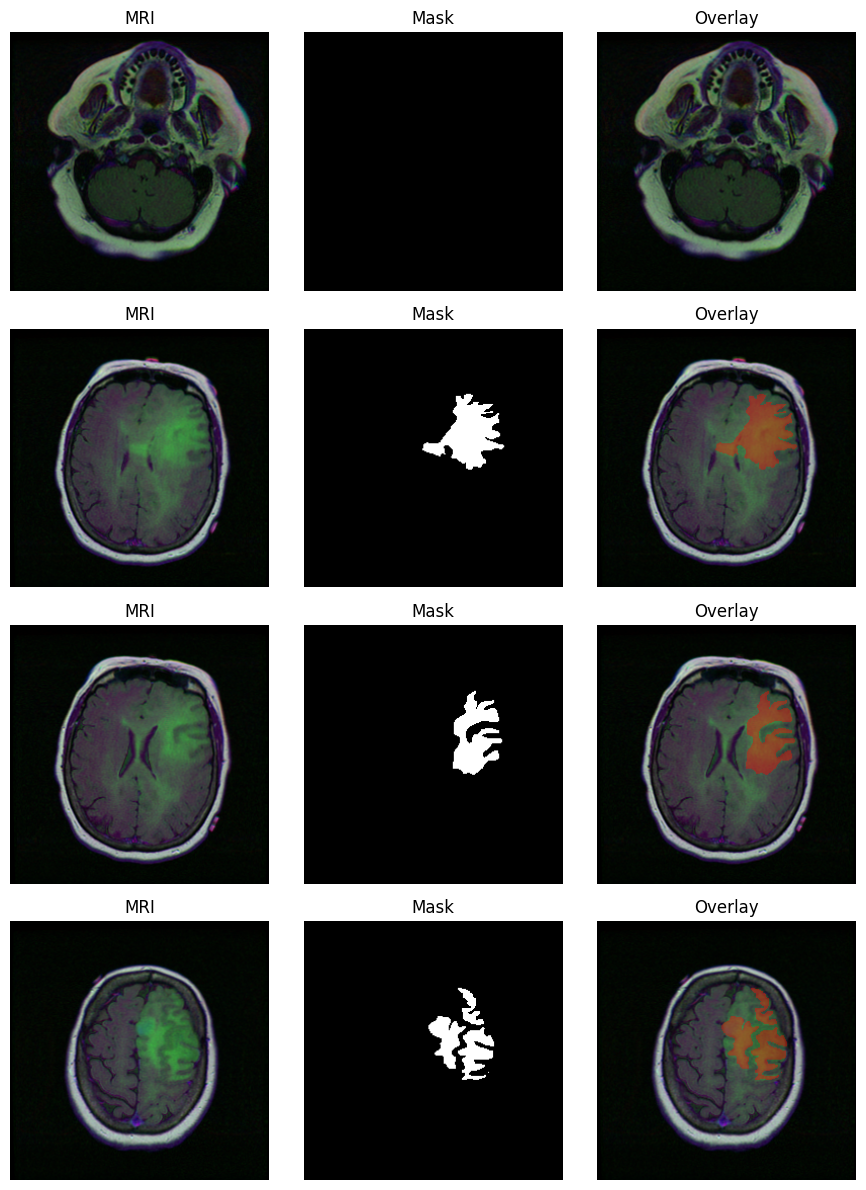

In [10]:
def plot_data(pairs, alpha=0.4):
    n = len(pairs)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))

    for i, (img_path, msk_path) in enumerate(pairs):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)          # cv2 legge in BGR
        msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)

        # overlay: the mask is red in the third column
        overlay = img.copy()
        overlay[msk > 0] = [255, 0, 0]
        blended = cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('MRI')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(msk, cmap='gray')
        axes[i, 1].set_title('Mask')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(blended)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

pairs = list(zip(df['images_paths'], df['masks_paths']))
plot_data(pairs[1:5])

### 2.5 Train / validation / test split 
First hold out 70% for training and 30% for the rest, then halve that remainder into validation and test sets.

In [ ]:
# create training set and validation/test set   
train_df, val_test_df = train_test_split(df, random_state = RANDOM_STATE, train_size= TRAIN_SPLIT)

# create validation and test set
val_df, test_df = train_test_split(val_test_df, train_size= TEST_SPLIT)


### 2.6 Data Generator
A batch generator streams the pairs from disk on the fly

**Batch generator:** builds a generator of aligned (image, mask) batches: each image and its mask receive identical geometric transforms.

In [12]:
def get_generator(df, size=256, batch_size=40, augment=False, aug_config = {}):
    rows = df[['images_paths', 'masks_paths']].to_numpy()
    
    datagen = ImageDataGenerator(**aug_config)   

    while True:
        np.random.shuffle(rows)
        for k in range(0, len(rows) - batch_size + 1, batch_size):
            X, Y = [], []
            for ip, mp in rows[k:k+batch_size]:
                img = cv2.resize(cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB), (size, size)).astype('float32')
                msk = cv2.resize(cv2.imread(mp, cv2.IMREAD_GRAYSCALE), (size, size),
                                 interpolation=cv2.INTER_NEAREST).astype('float32')[..., None]
                if augment:
                    t = datagen.get_random_transform(img.shape)   # get transformation
                    img = datagen.apply_transform(img, t)          
                    msk = datagen.apply_transform(msk, t)          
                X.append(img / 255.0)
                Y.append((msk > 127).astype('float32'))
            yield np.stack(X), np.stack(Y)

**Create the generators:** training gets light augmentation (rotation, shifts, shear, zoom, horizontal flip); validation and test don't use augmentation to stay faithful to the original images.

In [13]:
img_size = 256
batch_size = 40

train_aug = dict(rotation_range=10,
                 width_shift_range=0.10,
                 height_shift_range=0.10,
                 shear_range=0.05,
                 zoom_range=0.15,
                 horizontal_flip=True,
                 fill_mode='nearest')

train_gen = get_generator(train_df, img_size, batch_size, augment=True, aug_config=train_aug)
val_gen = get_generator(val_df, img_size, batch_size, augment=False)
test_gen = get_generator(test_df, img_size, batch_size, augment=False)

## **3. Metrics**

Segmentation quality can't be judged by pixel accuracy alone: since the tumor covers only a tiny fraction of each MRI (where the background class might dominate the metric), a model that predicts "no tumor" everywhere would already score above 99%. For this reason we rely on overlap-based metrics that focus on the region of interest.

Both metrics compare the predicted mask against the ground-truth mask through their intersection (pixels marked as tumor in both) and are defined below. A small smooth term is added to numerator and denominator to avoid division by zero and to stabilize the gradient when a mask is empty.

**Dice coefficient**
$$
Dice = \frac{2*|A \cap B|}{|A| + |B|}
$$
Measures the overlap between prediction $A$ and ground truth $B$, weighting the intersection twice. It ranges from 0 (no overlap) to 1 (perfect match). This metric is especially useful in scenarios where the focus is on correctly identifying the segmented areas without much concern for the non-segmented areas. It is widely used in medical imaging for tasks such as tumor detection and organ segmentation, where the precise identification of regions is crucial.

**Dice loss**
$$
Dice_{loss} = -Dice
$$
Since training minimizes the loss, we take the negative Dice: maximizing overlap becomes minimizing the loss. This is used as the objective function to optimize the network directly on the metric we care about.

**IoU (Intersection over Union / Jaccard index) coefficient**
$$
IoU = \frac{|A \cap B|}{|A \cup B|} = \frac{|A \cap B|}{|A| + |B| - |A \cap B|}
$$
A stricter overlap measure than Dice (it penalizes errors more heavily), also ranging from 0 to 1.

Dice and IoU are used as monitoring metrics during training and evaluation, while Dice loss drives the optimization.



In [ ]:
# dice coefficient
def dice_coef(y_true, y_pred, smooth=100):
    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)

    intersection = K.sum(y_true_flatten * y_pred_flatten)
    union = K.sum(y_true_flatten) + K.sum(y_pred_flatten)
    return (2 * intersection + smooth) / (union + smooth)

# dice loss
def dice_loss(y_true, y_pred, smooth=100):
    return -dice_coef(y_true, y_pred, smooth)

# iou coefficient
def iou_coef(y_true, y_pred, smooth=100):
    intersection = K.sum(y_true * y_pred)
    sum = K.sum(y_true + y_pred)
    iou = (intersection + smooth) / (sum - intersection + smooth)
    return iou

## **4. Model**

The segmentation is tackled with a **U-Net**, an encoder–decoder architecture. Its name comes from the symmetric "U" shape: a contracting branch that compresses the image and an expansive branch that reconstructs it, linked by horizontal *skip connections*. For every pixel of the input MRI `(256×256×3)`, the network outputs the probability of belonging to the tumor region, producing a `(256×256×1)` mask.

<p align="center">
  <img src="assets/img/u_net.png" alt="U-Net architecture" width="700">
</p>

**Contracting path (encoder).** Four stacked `encoder_block`s (64 → 128 → 256 → 512 filters). Each block applies two `3×3` convolutions with ReLU activation to extract features, followed by a `2×2` MaxPooling that halves the spatial resolution: the network trades spatial detail for increasingly abstract context.

**Bottleneck.** At the deepest point, two `3×3` convolutions with 1024 filters: the layer with the richest representation and the lowest spatial resolution.

**Expansive path (decoder).** Four symmetric `decoder_block`s (512 → 256 → 128 → 64). Each block uses a `2×2` `Conv2DTranspose` to double the resolution, then **concatenates the skip connections** coming from the matching encoder level — restoring the spatial detail lost during pooling and finally applies two `3×3` convolutions with ReLU. A `Resizing` layer aligns the feature-map dimensions before concatenation.

**Output.** A `1×1` convolution with a **sigmoid** activation produces the final mask, where each pixel holds a value in [0, 1] interpretable as the probability of tumor.

The model is compiled with the **Adamax** optimizer (lr = 0.001), **Dice loss** as the objective function, and IoU / Dice / accuracy as monitoring metrics.


In [15]:
def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = tf.keras.layers.Activation('relu')(x)
    
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    
    return x

def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)

    skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(skip_features)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

def unet(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)
    
    # Contracting Path (Encoder)
    s1 = encoder_block(inputs, 64)
    s2 = encoder_block(s1, 128)
    s3 = encoder_block(s2, 256)
    s4 = encoder_block(s3, 512)
    
    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(s4)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)
    
    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    
    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='valid', activation='sigmoid')(d4)
    
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

In [16]:
model = unet()
model.compile(Adamax(learning_rate= 0.001), loss= dice_loss, metrics= ['accuracy', iou_coef, dice_coef])

model.summary()

I0000 00:00:1783703247.482276      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ activation_4[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

## **5. Training**

With the architecture defined, the network is trained end-to-end on the batches streamed by `train_gen`, while `val_gen` monitors generalization on unseen data at every epoch.

**Monitoring.** The `plot_train` helper visualizes the learning curves for each metric (IoU, Dice, loss, accuracy), plotting training vs. validation and highlighting the best epoch on every panel. Comparing the two curves is the primary tool to diagnose the training dynamics: closely tracking curves indicate healthy learning

In [ ]:
def plot_train(hist):
    """Training vs Validation History Metrics"""
    history = hist.history
    epochs = range(1, len(history['loss']) + 1)

    # (key train, key val, label, criterion) — 'max' for metrics, 'min' for loss
    panels = [
        ('iou_coef',  'val_iou_coef',  'IoU',      'max'),
        ('dice_coef', 'val_dice_coef', 'Dice',     'max'),
        ('loss',      'val_loss',      'Loss',     'min'),
        ('accuracy',  'val_accuracy',  'Accuracy', 'max'),
    ]

    plt.style.use('fivethirtyeight')
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    for ax, (tr_key, val_key, name, criterion) in zip(axes.flat, panels):
        tr_curve, val_curve = history[tr_key], history[val_key]

        # best epoch based on validation set
        pick = np.argmin if criterion == 'min' else np.argmax
        best = int(pick(val_curve))

        ax.plot(epochs, tr_curve,  color='crimson',  linewidth=2, label=f'Train {name}')
        ax.plot(epochs, val_curve, color='seagreen', linewidth=2, label=f'Validation {name}')
        ax.scatter(best + 1, val_curve[best], s=140, color='navy', zorder=5,
                   label=f'Best epoch: {best + 1}')

        ax.set(title=f'{name}', xlabel='Epoch', ylabel=name)
        ax.legend()
    
    fig.suptitle('Training vs Validation History Metrics', fontsize=16, fontweight='bold')
    fig.tight_layout()
    plt.show()

**Setup.** Training runs for **70 epochs** with a **batch size of 40**. Since the generators yield batches indefinitely, `steps_per_epoch` and `validation_steps` are set to `len(df) // batch_size`, so that one epoch corresponds to a full pass over the training (and validation) samples.

**Checkpointing.** A `ModelCheckpoint` callback saves the weights to `unet.keras` with `save_best_only=True`: only the epoch achieving the lowest validation loss is kept on disk. This acts as an implicit safeguard against overfitting. Even if later epochs degrade, the best-performing model is preserved and can be reloaded for evaluation and inference.

**Optimization recap.** The network is optimized with **Adamax** (lr = 0.001) against the **Dice loss**, i.e. training directly maximizes the overlap between predicted and ground-truth masks. IoU, Dice and accuracy are tracked on both training and validation sets throughout the run.


In [18]:
epochs = 70
batch_size = 40
callbacks = [ModelCheckpoint('unet.keras', verbose=0, save_best_only=True)]

history = model.fit(train_gen,
                    steps_per_epoch=len(train_df) // batch_size,
                    epochs=epochs,
                    verbose=1,
                    callbacks=callbacks,
                    validation_data = val_gen,
                    validation_steps=len(val_df) // batch_size)

Epoch 1/70


2026-07-10 17:07:45.207506: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv (f32[40,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[40,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-07-10 17:07:45.266246: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.058958539s
Trying algorithm eng12{k11=2} for conv (f32[40,128,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[40,128,128,128]{3,2,1,0}, f32[128,128,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__c

137/137 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8994 - dice_coef: 0.3675 - iou_coef: 0.2465 - loss: -0.3675 - val_accuracy: 0.9867 - val_dice_coef: 0.5044 - val_iou_coef: 0.3428 - val_loss: -0.5044
Epoch 2/70
137/137 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9900 - dice_coef: 0.5189 - iou_coef: 0.3594 - loss: -0.5189 - val_accuracy: 0.9901 - val_dice_coef: 0.5567 - val_iou_coef: 0.3949 - val_loss: -0.5567
Epoch 3/70
137/137 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9911 - dice_coef: 0.5621 - iou_coef: 0.4003 - loss: -0.5621 - val_accuracy: 0.9933 - val_dice_coef: 0.6322 - val_iou_coef: 0.4677 - val_loss: -0.6322
Epoch 4/70
137/137 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9926 - dice_coef: 0.6265 - iou_coef: 0.4647 - loss: -0.6265 - val_accuracy: 0.9936 - val_dice_coef: 0.6791 - val_iou_coef: 0.5205 - val_loss: -0.6791
Epoch 5/70
137/137 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9936 - dice_coef: 0.6679 - iou_coef: 0.5082 - loss: -0.6679 - val_accuracy: 

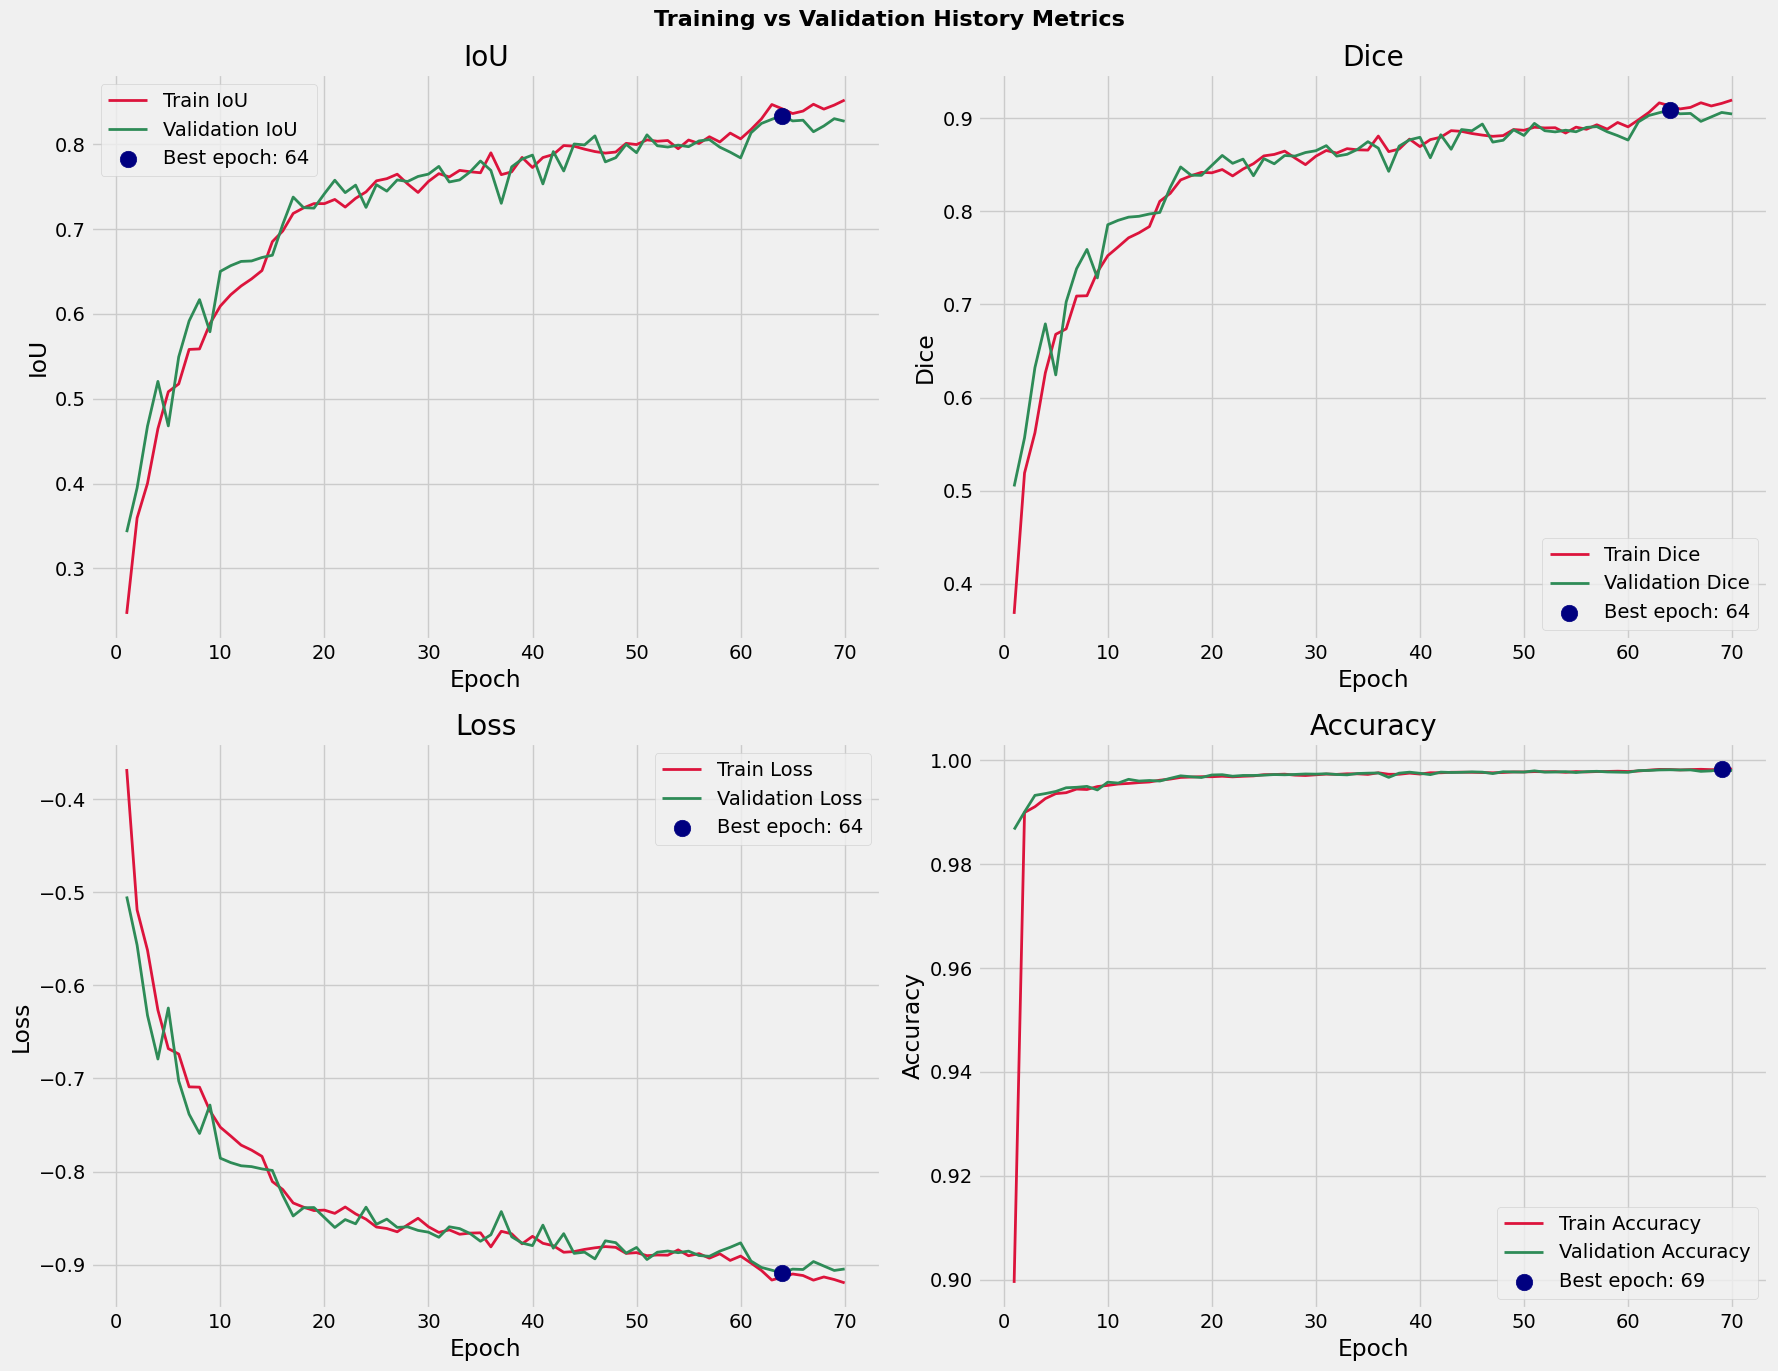

In [19]:
plot_train(history)

## **6. Load model** (optional)

Once you have fully run the notebook and obtained the `unet.keras` file, you can upload the model as follows:

1. In the **Input** section, click **Upload**.
2. Select **New Model**.
3. Browse for the file (if you saved the model on your PC); otherwise, you can choose one of the other available options.
4. Fill in the form: choose **Keras** for the framework, and set the other fields as you prefer.
5. Click **Create** and wait for the system to finish uploading.
6. Go to the **Models** section and find the `unet.keras` file. You can copy its file path by clicking on the right button.
7. Paste the file path into the `model_path` variable.

To use the already-trained model you do **NOT** need to run the training cells. Run **only** these cells, **in this order**:

1. **Library imports** (first code cell — `import kagglehub ... from tensorflow.keras.optimizers import Adamax`)
2. **Global settings** (`TRAIN_SPLIT`, `TEST_SPLIT`, `RANDOM_STATE` and the seeds)
3. **Section 1: Download dataset** (`kagglehub.dataset_download(...)`)
4. **Section 2.1: Locate the masks** (`masks_paths = glob(...)`)
5. **Section 2.2: Pair images with masks** (building the `DataFrame df`)
6. **Section 2.5: Train / validation / test split** (creates `train_df`, `val_df`, `test_df`, required for evaluation and prediction)
7. **Section 3: Metrics** (definition of `dice_coef`, `dice_loss`, `iou_coef`: needed to recompile the loaded model)
8. **Section 6: Load model**: remove the `"""` triple quotes that comment out the cell, set `model_path` to the path of the uploaded `unet.keras` file, and run the cell. This loads the model and recompiles it with the metrics.

At this point the `model` variable holds the trained network, and you can run directly:

9. **Section 7: Evaluation** (`load_split` + `model.evaluate`)
10. **Section 8: Prediction** (visualization of the predictions)


In [20]:
# Uncomment if you need to use this section

"""
model_path = "/kaggle/input/models/.../model-checkpoint/keras/default/1/unet.keras"

model = keras.models.load_model(
    model_path,
    compile=False
)
model.compile(
    optimizer="adam",
    loss=dice_loss,
    metrics=["accuracy", iou_coef, dice_coef],   # usa i nomi ESATTI delle tue metriche
)
"""

'\nmodel_path = "/kaggle/input/models/.../model-checkpoint/keras/default/1/unet.keras"\n\nmodel = keras.models.load_model(\n    model_path,\n    compile=False\n)\nmodel.compile(\n    optimizer="adam",\n    loss=dice_loss,\n    metrics=["accuracy", iou_coef, dice_coef],   # usa i nomi ESATTI delle tue metriche\n)\n'

## **7. Evaluation**

The trained model is assessed on the **hold-out test set**, which was never seen during training or validation, to obtain an unbiased estimate of its segmentation performance.

**Data loading.** Unlike training, evaluation does not stream batches from a generator: the helper `load_split` reads the whole test split into memory, resizing each MRI and mask to `256×256`, normalizing the images to [0, 1] and binarizing the masks. This yields the arrays `X_test` and `Y_test` passed to `model.evaluate`.

In [21]:
def load_split(df, size=256):
    X, Y = [], []
    for ip, mp in df[['images_paths', 'masks_paths']].to_numpy():
        img = cv2.resize(cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB), (size, size))
        msk = cv2.resize(cv2.imread(mp, cv2.IMREAD_GRAYSCALE), (size, size),
                         interpolation=cv2.INTER_NEAREST)
        X.append(img.astype('float32') / 255.0)
        Y.append((msk > 127).astype('float32')[..., None])
    return np.stack(X), np.stack(Y)

X_test, Y_test = load_split(test_df)
test_eval = model.evaluate(X_test, Y_test, batch_size=32, verbose=1, return_dict=True)

print("Test Set Loss:", test_eval["loss"])
print("Test Set Accuracy:", test_eval["accuracy"])
print("Test Set IoU:", test_eval["iou_coef"])
print("Test Set Dice:", test_eval["dice_coef"])

36/37 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.9983 - dice_coef: 0.9160 - iou_coef: 0.8469 - loss: -0.9160

2026-07-10 20:19:00.012019: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-10 20:19:00.251393: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-10 20:19:01.453044: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-10 20:19:01.716986: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


37/37 ━━━━━━━━━━━━━━━━━━━━ 52s 820ms/step - accuracy: 0.9982 - dice_coef: 0.9092 - iou_coef: 0.8353 - loss: -0.9091
Test Set Loss: -0.9090797901153564
Test Set Accuracy: 0.9982079863548279
Test Set IoU: 0.8352769613265991
Test Set Dice: 0.9091764092445374


**Results.** The model is scored with the same objective and metrics used during training:

| Metric   | Test score |
|----------|-----------|
| Loss (−Dice) | −0.909 |
| Accuracy | 0.998 |
| IoU      | 0.835 |
| Dice     | 0.909 |


## **8. Prediction**

Beyond aggregate metrics, this section provides a **qualitative check** by visualizing the model's predictions on individual test images.

**Sample selection.** You can choose which test examples show using a fixed `index_list`.

**Inference.** For each selected slice the MRI is resized to `256×256` and normalized to [0, 1], then fed to `model.predict`. The network returns a per-pixel probability map, which is turned into a binary mask by thresholding at **0.5** (pixels above the threshold are labeled as tumor).

**Visualization.** Each example is shown on three panels: the input **MRI**, the **ground-truth mask**, and the **predicted mask** so the model's output can be compared side by side with the manual annotation. The predicted regions closely follow the reference masks in location and shape, visually confirming the strong Dice/IoU scores reported in the evaluation.


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


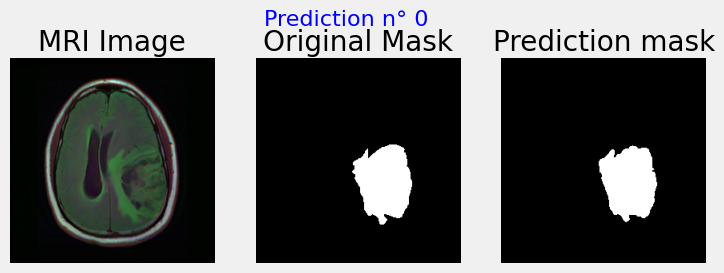

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


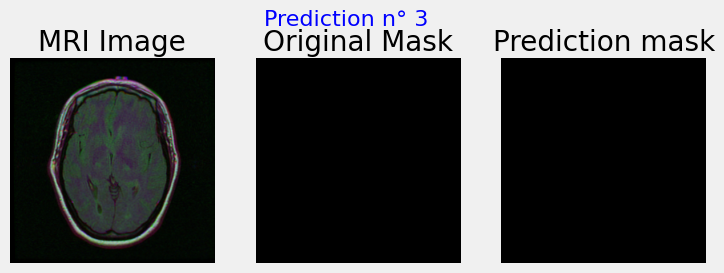

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


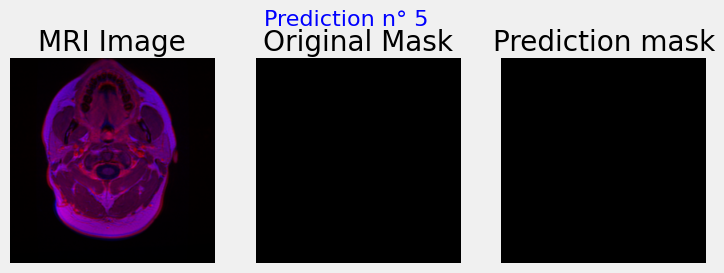

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


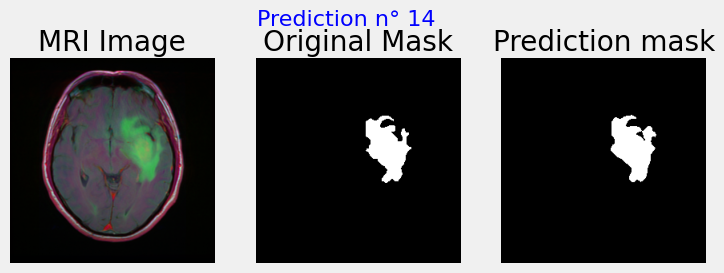

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


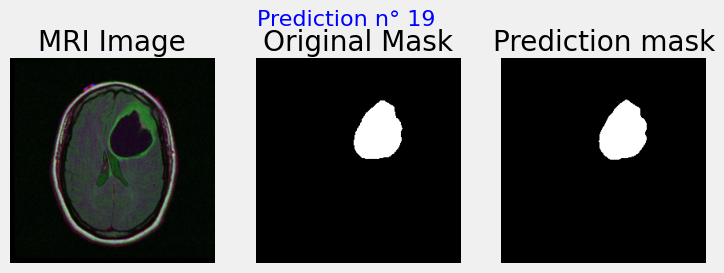

In [22]:
index_list = [0,3,5,14,19]
for i in index_list:
    
    # MRI image
    img = cv2.imread(test_df['images_paths'].iloc[i])
    img = cv2.resize(img, (256, 256))
    img = img/255
    img = img[np.newaxis, :, :, : ]
    mri_img = np.squeeze(img)

    # Original mask
    orig_mask = np.squeeze(cv2.imread(test_df['masks_paths'].iloc[i]))
    
    # Prediction img
    predict_mask = model.predict(img)
    predict_mask = ((np.squeeze(predict_mask) > 0.5 ) * 255).astype(np.uint8)

    plt.figure(figsize=(8, 3))
    plt.suptitle(f"Prediction n° {i}", fontsize = 16, color = "blue")
    
    plt.subplot(1, 3, 1)
    plt.imshow(mri_img)
    plt.title('MRI Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(orig_mask)
    plt.title('Original Mask')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(predict_mask, cmap = "grey")
    plt.title('Prediction mask')
    plt.axis('off')
    
    plt.show()


## **9 .Conclusions**

This project built an end-to-end pipeline for the segmentation of FLAIR abnormalities in brain MR images, from raw data to pixel-level predictions.

Starting from the **LGG Segmentation Dataset** (110 patients, 7858 image/mask pairs), each MRI was paired with its manual annotation and fed through an input pipeline handling resizing, normalization and light data augmentation. A **U-Net** was trained with the **Dice loss**, a choice deliberately aligned with the segmentation objective and robust to the strong class imbalance between tumor and background.

On the hold-out test set the model reached a **Dice of ~0.91** and an **IoU of ~0.84**. The qualitative predictions confirmed these figures, with the estimated masks closely matching the manual ones in position and shape.

**Possible extensions.** Several directions could push the results further:
- experimenting with stronger backbones or attention-based variants (e.g. Attention U-Net, U-Net++);
- adding post-processing (morphological cleanup, connected-component filtering) to remove spurious predictions;
- adopting a proper cross-validation scheme and richer augmentation to further improve robustness;

## **10. References**

This dataset is used in:

- Mateusz Buda, Ashirbani Saha, Maciej A. Mazurowski. *"Association of genomic subtypes of lower-grade gliomas with shape features automatically extracted by a deep learning algorithm."* Computers in Biology and Medicine, 2019.
- Maciej A. Mazurowski, Kal Clark, Nicholas M. Czarnek, Parisa Shamsesfandabadi, Katherine B. Peters, Ashirbani Saha. *"Radiogenomics of lower-grade glioma: algorithmically-assessed tumor shape is associated with tumor genomic subtypes and patient outcomes in a multi-institutional study with The Cancer Genome Atlas data."* Journal of Neuro-Oncology, 2017.